In this notebook, we develop a Convolutional Neural Network (CNN) to classify images of waste into six categories: glass, metal, paper, plastic, cardboard, and general trash.

We first need to import the neccessary libraries to create the convolutional neural network using pytorch.

In [15]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import random

Now that we have the relevant imports, we can create a garbage dataset class that contains information such as labels and images. In addition, the class should contain a method for returning the length and for fetching information about a specific item.

In [9]:
def load_and_preprocess_data(data_dir, img_size=(128, 128)):
    X = []
    y = []
    categories = []

    for d in os.listdir(data_dir):
        if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.'):
            categories.append(d)
    
    print("Found categories:", categories)
    categories.sort()
    
    print("Loading and preprocessing images...")
    for category_idx, category in enumerate(categories):
        category_path = os.path.join(data_dir, category)
        if not os.path.isdir(category_path):
            continue
        
        print(f"Processing Category: {category} ({category_idx})")
        image_files = [f for f in os.listdir(category_path) if f.lower().endswith('.jpg')]
        
        for img_file in tqdm(image_files[:500]):
            img_path = os.path.join(category_path, img_file)
            img = cv2.imread(img_path)
            img = cv2.resize(img, img_size)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb = img_rgb / 255.0
            
            X.append(img_rgb)
            y.append(category_idx)

    return np.array(X), np.array(y), categories

This function loads and preprocesses image data from a specified directory. In this case each subdirectory represents a category. It reads up to 500 ".jpg" images per category, resizing them to 128x128 pixels converting them to RGB and normalizes pixel values (between 0 and 1).

Now we define the CNN Model.

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  
            nn.ReLU(),
            nn.MaxPool2d(2),  

            nn.Conv2d(32, 64, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2), 

            nn.Conv2d(64, 128, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2),  
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


This class is a Pytorch model with three convulional layers for features extraction and two fully connected layers for classifications. It uses Relu activations (max(0,n)), max pooling, and dropout for regularization. The final layers outputs class predictions. Dropout for regularization works by randomly setting a fraction of the neurons to zero to prevent regularisation.

Now let's train the model:

In [11]:
def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")

        evaluate_model(model, val_loader, verbose=True)


This function trains the CNN model using the training data over a specified number of epochs. It uses the Adam optimizer and cross-entropy loss to update the model's weights based on prediction error. After each epoch, it prints the average training loss and evaluates the model's performance on the validation set. This helps monitor learning progress and prevent overfitting. Overfitting happens when our model is overadapted to it's training data and doesn't perform well on external data.

In [12]:
def evaluate_model(model, loader, verbose=False):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())

    if verbose:
        print("Accuracy:", accuracy_score(y_true, y_pred))
        print("Classification Report:\n", classification_report(y_true, y_pred))



This function evaluates the model on a dataset and returns prediction results. If "verbose" is "true", it prints the accuracy and a detailed classification report.

Found categories: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Loading and preprocessing images...
Processing Category: cardboard (0)


100%|██████████| 403/403 [00:00<00:00, 1706.71it/s]


Processing Category: glass (1)


100%|██████████| 500/500 [00:00<00:00, 1843.88it/s]


Processing Category: metal (2)


...

Processing Category: plastic (4)


100%|██████████| 482/482 [00:00<00:00, 1880.95it/s]


Processing Category: trash (5)


100%|██████████| 137/137 [00:00<00:00, 1908.45it/s]


Data shape: (2432, 128, 128, 3) (2432,)


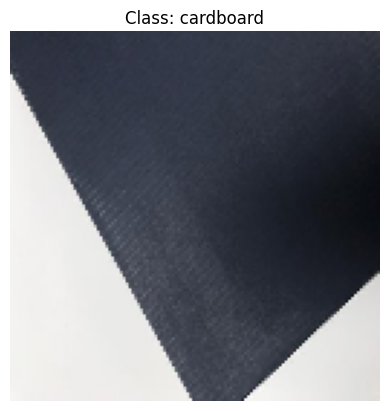

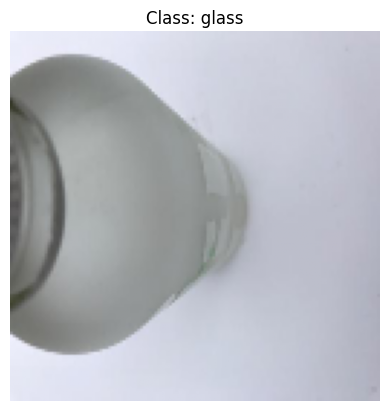

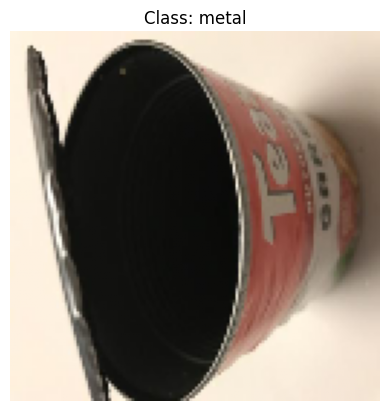

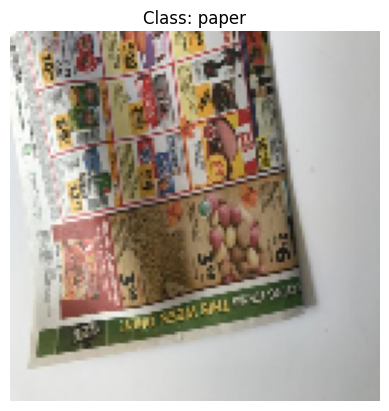

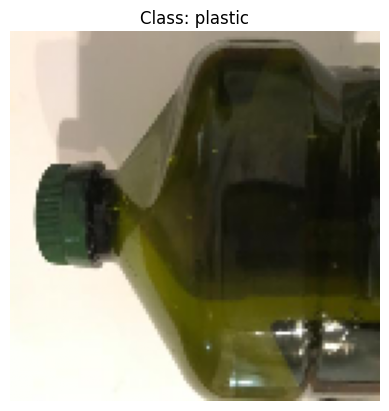

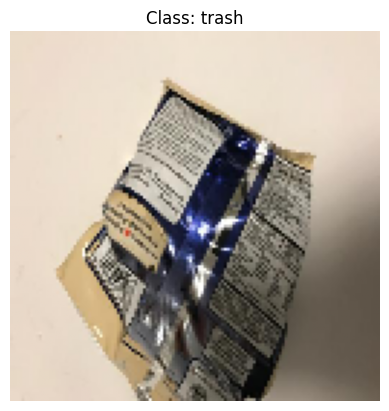

In [16]:
DATA_DIR = "./Garbage classification" 
X, y, categories = load_and_preprocess_data(DATA_DIR)
print("Data shape:", X.shape, y.shape)
num_classes = len(categories)

for class_idx in range(len(categories)):
    img = X[y == class_idx][random.randint(0,len(X[y == class_idx])-1)] 
    plt.imshow(img)
    plt.title(f"Class: {categories[class_idx]}")
    plt.axis('off')
    plt.show()

In [19]:
# Train/test split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.transpose(0, 3, 1, 2), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.transpose(0, 3, 1, 2), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
# Create data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=num_classes).to(device)
# Train and evaluate
train_model(model, train_loader, val_loader, num_epochs=20)
# Save model (optional)
torch.save(model.state_dict(), "simple_cnn_model.pth")

Epoch [1/20], Loss: 1.5616
Accuracy: 0.46406570841889117
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.64      0.72        81
           1       0.58      0.21      0.31       100
           2       0.36      0.73      0.48        82
           3       0.56      0.24      0.34       100
           4       0.39      0.71      0.50        97
           5       0.00      0.00      0.00        27

    accuracy                           0.46       487
   macro avg       0.45      0.42      0.39       487
weighted avg       0.51      0.46      0.43       487



c:\Users\sioul\Documents\Highgate school\EPQ 2.0\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sioul\Documents\Highgate school\EPQ 2.0\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sioul\Documents\Highgate school\EPQ 2.0\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Epoch [2/20], Loss: 1.2912
Accuracy: 0.5195071868583162
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.51      0.65        81
           1       0.62      0.34      0.44       100
           2       0.39      0.59      0.47        82
           3       0.50      0.63      0.56       100
           4       0.48      0.64      0.55        97
           5       0.56      0.19      0.28        27

    accuracy                           0.52       487
   macro avg       0.57      0.48      0.49       487
weighted avg       0.57      0.52      0.52       487

Epoch [3/20], Loss: 1.1286
Accuracy: 0.6036960985626283
Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.85      0.72        81
           1       0.55      0.58      0.57       100
           2       0.57      0.48      0.52        82
           3       0.66      0.76      0.70       100
           4       0.71   

This code loads and preprocesses image data, then splits it into training and validation sets. It converts the data into PyTorch tensors and creates data loaders for batching. The model is initialized on GPU if available, trained on the training set, and evaluated on the validation set. Finally, the trained model is saved to a file.